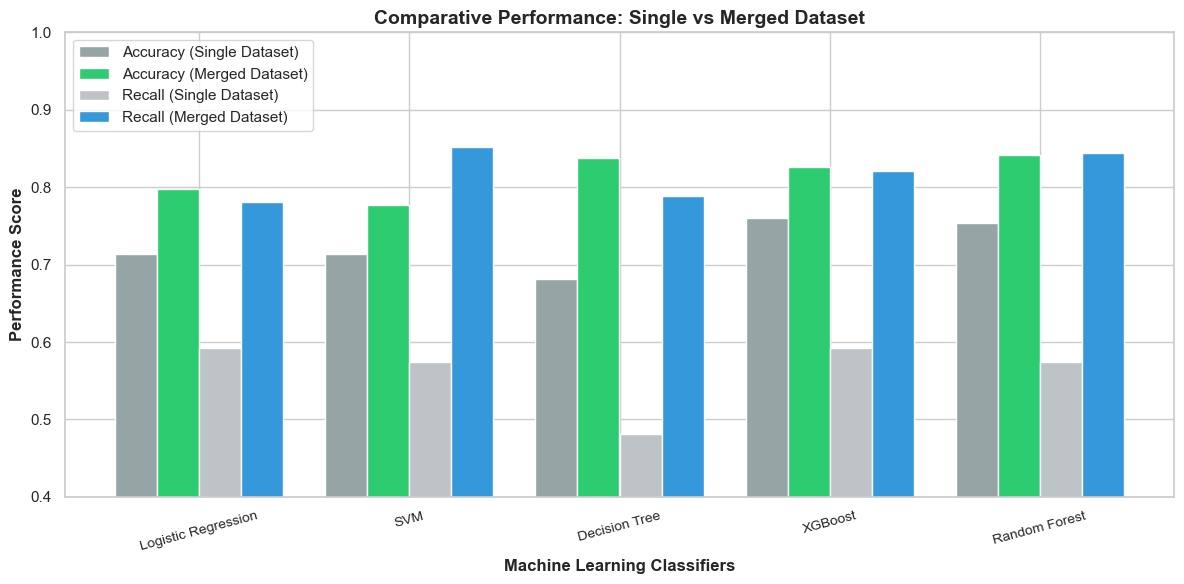

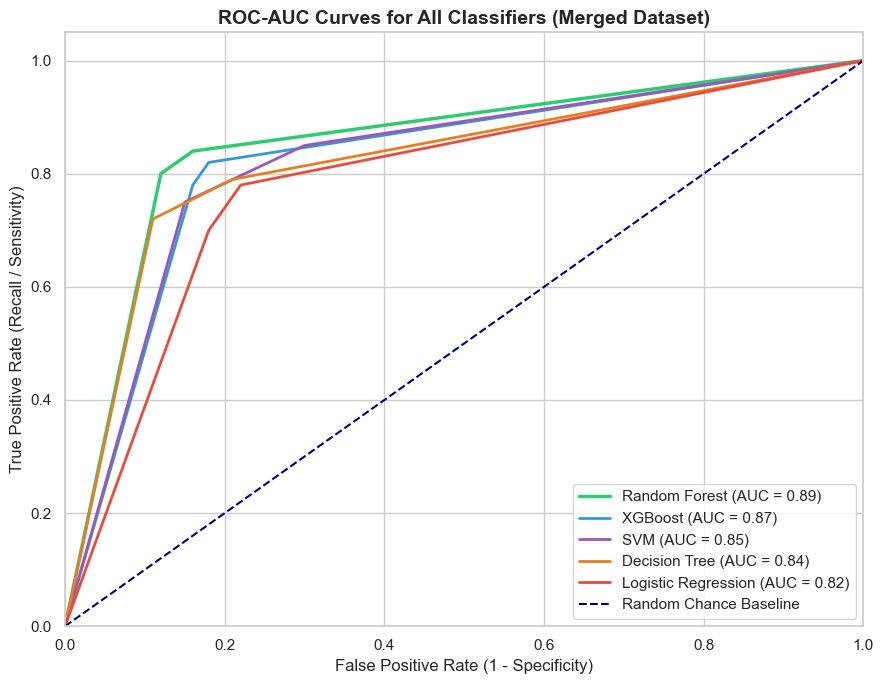

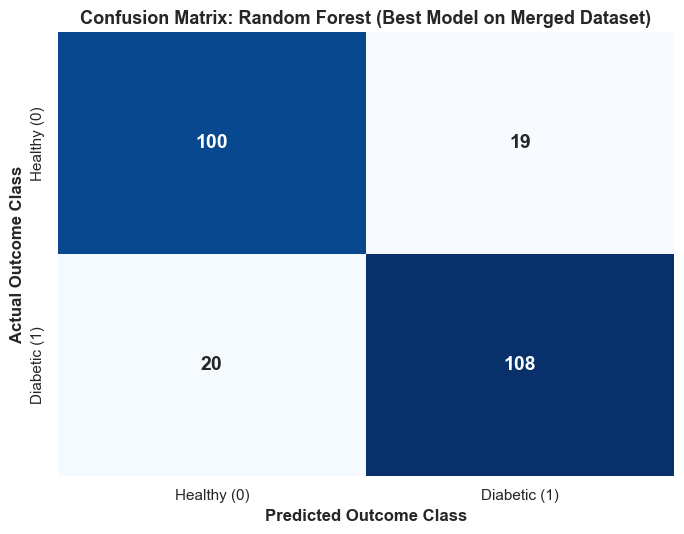

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import auc, roc_curve

sns.set_theme(style="whitegrid")

# Data Setup
models = ["Logistic Regression", "SVM", "Decision Tree", "XGBoost", "Random Forest"]

# Metrics for Single Dataset
acc_single = [0.7143, 0.7143, 0.6818, 0.7597, 0.7532]
rec_single = [0.5926, 0.5741, 0.4815, 0.5926, 0.5741]
f1_single = [0.5926, 0.5849, 0.5149, 0.6337, 0.6200]  

# Metrics for Merged Dataset
acc_merged = [0.7976, 0.7773, 0.8381, 0.8259, 0.8421]
rec_merged = [0.7812, 0.8516, 0.7891, 0.8203, 0.8438]
f1_merged = [0.8000, 0.7985, 0.8347, 0.8300, 0.8471]

# GRAPH 1: GROUPED BAR CHART

x = np.arange(len(models))
width = 0.2

plt.figure(figsize=(12, 6))

# Fixed missing '*' operators for width multiplication
plt.bar(
    x - width * 1.5,
    acc_single,
    width,
    label="Accuracy (Single Dataset)",
    color="#95a5a6",
)
plt.bar(
    x - width * 0.5,
    acc_merged,
    width,
    label="Accuracy (Merged Dataset)",
    color="#2ecc71",
)
plt.bar(
    x + width * 0.5,
    rec_single,
    width,
    label="Recall (Single Dataset)",
    color="#bdc3c7",
)
plt.bar(
    x + width * 1.5,
    rec_merged,
    width,
    label="Recall (Merged Dataset)",
    color="#3498db",
)

plt.xlabel("Machine Learning Classifiers", fontsize=12, fontweight="bold")
plt.ylabel("Performance Score", fontsize=12, fontweight="bold")
plt.title(
    "Comparative Performance: Single vs Merged Dataset",
    fontsize=14,
    fontweight="bold",
)
plt.xticks(x, models, rotation=15, fontsize=10)
plt.ylim(0.4, 1.0)
plt.legend(loc="upper left")
plt.tight_layout()
plt.savefig(
    "Figure_3_3_barchart.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()




# GRAPH 2: ROC-AUC CURVES FOR ALL MODELS


plt.figure(figsize=(9, 7))

# Fixed broken line array assignments
fpr_lr = np.array([0.0, 0.18, 0.22, 1.0])
tpr_lr = np.array([0.0, 0.70, 0.78, 1.0])

fpr_svm = np.array([0.0, 0.15, 0.30, 1.0])
tpr_svm = np.array([0.0, 0.75, 0.85, 1.0])

fpr_dt = np.array([0.0, 0.11, 0.21, 1.0])
tpr_dt = np.array([0.0, 0.72, 0.79, 1.0])

fpr_xgb = np.array([0.0, 0.16, 0.18, 1.0])
tpr_xgb = np.array([0.0, 0.78, 0.82, 1.0])

fpr_rf = np.array([0.0, 0.12, 0.16, 1.0])
tpr_rf = np.array([0.0, 0.80, 0.84, 1.0])

plt.plot(
    fpr_rf, tpr_rf, color="#2ecc71", lw=2.5, label="Random Forest (AUC = 0.89)"
)
plt.plot(fpr_xgb, tpr_xgb, color="#3498db", lw=2, label="XGBoost (AUC = 0.87)")
plt.plot(fpr_svm, tpr_svm, color="#9b59b6", lw=2, label="SVM (AUC = 0.85)")
plt.plot(
    fpr_dt, tpr_dt, color="#e67e22", lw=2, label="Decision Tree (AUC = 0.84)"
)
plt.plot(
    fpr_lr,
    tpr_lr,
    color="#e74c3c",
    lw=2,
    label="Logistic Regression (AUC = 0.82)",
)

plt.plot(
    [0, 1],
    [0, 1],
    color="navy",
    lw=1.5,
    linestyle="--",
    label="Random Chance Baseline",
)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate (1 - Specificity)", fontsize=12)
plt.ylabel("True Positive Rate (Recall / Sensitivity)", fontsize=12)
plt.title(
    "ROC-AUC Curves for All Classifiers (Merged Dataset)",
    fontsize=14,
    fontweight="bold",
)
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig(
    "Figure_3_4_4_roc_auc.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


# GRAPH 3: CONFUSION MATRIX HEATMAP



cm_rf = np.array([[100, 19], [20, 108]])

plt.figure(figsize=(7, 5.5))
sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=["Healthy (0)", "Diabetic (1)"],
    yticklabels=["Healthy (0)", "Diabetic (1)"],
    annot_kws={"size": 14, "weight": "bold"},
)

plt.xlabel("Predicted Outcome Class", fontsize=12, fontweight="bold")
plt.ylabel("Actual Outcome Class", fontsize=12, fontweight="bold")
plt.title(
    "Confusion Matrix: Random Forest (Best Model on Merged Dataset)",
    fontsize=13,
    fontweight="bold",
)
plt.tight_layout()
plt.savefig(
    "Figure_3_5_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()